# Lightweight Network Intrusion Detection System (IDS)
## CA2 Project – Problem Solving for Industry

**Students:**  
- Sander Luiz Santos Soares — **2022164**  
- Thiago Gonçalves da Costa — **2022161**

**College:** CCT College Dublin  
**Programme:** BSc (Hons) in Computing in IT  
**Module:** Problem Solving for Industry  
**Assessment:** CA2 Project  
**Lecturers:** Muhammad Iqbal, Ken Healy  
**Submission Type:** Jupyter Notebook / Python-based IDS prototype  

## Introduction

This project proposes the development of a **Lightweight Network Intrusion Detection System (IDS)** using **Python** and **machine learning** techniques to identify suspicious or potentially malicious network traffic. The main goal is to support the detection of anomalous behaviour in network flows and help organisations identify threats such as DoS, DDoS, brute force activity, port scanning, web attacks, infiltration, and other suspicious patterns.

The proposed solution is designed as a **lightweight and affordable prototype**, especially suitable for **small and medium-sized enterprises (SMEs)**, schools, clinics, small offices, and managed service providers that may not have dedicated cybersecurity teams or advanced monitoring infrastructure. The system aims to reduce the manual effort required to inspect traffic logs and improve the speed of suspicious traffic detection.

This notebook will document the technical development of the project, including **data understanding, preprocessing, feature selection, model training, evaluation, and prototype preparation**, following the logic of the **CRISP-DM framework** required in the CA2 brief. 

The project uses the **CIC-IDS2017** dataset, a public cybersecurity dataset developed by the **Canadian Institute for Cybersecurity**, containing labelled network traffic with both benign and malicious activity. This makes it suitable for building and testing machine learning models for intrusion detection.

The main technologies selected for this project are **Python**, **Scikit-learn**, and **Streamlit**. Python and Scikit-learn will be used for data preprocessing, machine learning model development, and evaluation, while Streamlit will support the creation of a simple dashboard interface for alerts and suspicious traffic summaries.

---

# 1. Data Understanding

## 1.1 Dataset Overview and Merging

The CICIDS2017 dataset is distributed across multiple CSV files, each representing different days of network traffic and specific attack scenarios (e.g., DDoS, PortScan, Web Attacks).

To ensure a comprehensive analysis and avoid bias from individual files, all datasets are merged into a single unified dataset. This allows the model to learn from a complete representation of both benign and malicious traffic patterns.

In [6]:
import pandas as pd
import glob

# Using glob to load all CSV files within the folder
files = glob.glob("Datasets/CICIDS2017/*.csv")


# Read and combine into one dataset
df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)

#notice some column have a space before, so using this to remove unwanted spaces.
df.columns = df.columns.str.strip()

# Clean ALL string data (some strings are with some Unusual character)
df = df.apply(lambda x: x.str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip() if x.dtype == "object" else x)

print("Number of files loaded:", len(files))
print("Dataset shape:", df.shape)

Number of files loaded: 8
Dataset shape: (2830743, 79)


---

## 1.2 Initial Data Exploration

After merging the datasets, an initial exploration is performed to understand the structure of the data. 
This includes examining the first rows, dataset dimensions, feature names, and data types.

In [3]:
# View first rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# Dataset shape
df.shape

(2830743, 79)

In [10]:
# Column names
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

---

## 1.3 Target Variable Analysis

The target variable in this dataset is the 'Label' column, which indicates whether a network flow is benign or corresponds to a specific type of attack.

To better understand the dataset, both the absolute count and percentage distribution of each class are analysed. This helps identify class imbalance, which is common in intrusion detection datasets and can impact model performance.

In [7]:
# Count values of each class
class_counts = df['Label'].value_counts()

# Percentage distribution
class_percentages = df['Label'].value_counts(normalize=True) * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

class_distribution

,Count,Percentage (%)
Label,,
BENIGN,2273097,80.300366
DoS Hulk,231073,8.162981
PortScan,158930,5.614427
DDoS,128027,4.522735
DoS GoldenEye,10293,0.363615
FTP-Patator,7938,0.280421
SSH-Patator,5897,0.208320
DoS slowloris,5796,0.204752
DoS Slowhttptest,5499,0.194260


---

## 1.4 Missing values Analysis

Checking for missing values is important to ensure data quality.<br>
Missing values can negatively impact model performance and must be handled during data preparation.

In [2]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Label                      0
Length: 79, dtype: int64

### Key observations:

The analysis shows that most features do not contain missing values, with only a small number of missing entries identified in specific features such as "Flow Bytes/s".

In the data preparation phase, these missing values will be handled by removing or imputing affected records. Given the relatively low number of missing values compared to the overall dataset size, removing rows with missing values is considered an appropriate approach that is unlikely to significantly impact the dataset.

This step will ensure data consistency and improve the reliability of the machine learning models.

---

## 1.5 Statistical Summary

A statistical summary of numerical features is generated to understand the distribution, central tendency, and variability of the dataset. This helps identify potential anomalies and outliers.

In [3]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


### Key Observations:

From the analysis, several important observations can be made:

- The dataset contains features with very large ranges (e.g., Flow Duration, Total Length of Packets), indicating high variability in network traffic behaviour.
- Some features contain zero values for a large portion of the dataset, which may indicate inactive flows or unused attributes.
- There are significant differences between minimum, median (50%), and maximum values, suggesting the presence of outliers.
- Certain features show extreme maximum values compared to their mean, reinforcing the likelihood of skewed distributions.

These observations indicate that feature scaling and potential outlier handling will be important in the data preparation phase to ensure stable and effective model performance.

---

### 1.6 Conclusion of Data Understanding:

- The dataset contains a large number of features, most of which are numerical.
- The target variable shows a significant class imbalance, with benign traffic dominating.
- Some features may contain missing values and will require cleaning.
- The dataset has high dimensionality, suggesting that feature selection will be important for building a lightweight IDS.

These observations will guide the data preparation and modelling stages.

---

## 2 Exploratory Data Analysis (EDA) – Multi-Class IDS

## 2.1 Class Distribution (Multi-Class)

The dataset is treated as a multi-class classification problem, where each class represents a specific type of network traffic, including benign traffic and various attack categories such as DDoS, PortScan, and Web Attacks.

Visualising the class distribution helps identify class imbalance and understand how different attack types are represented in the dataset.

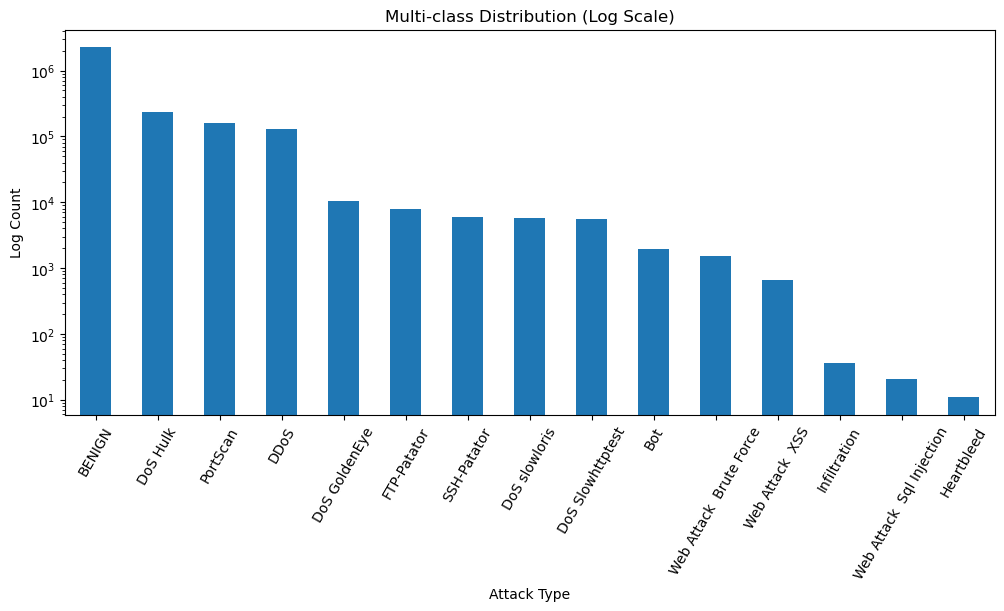

In [8]:
df['Label'].value_counts().plot(kind='bar', figsize=(12,5))

plt.yscale('log')  # KEY CHANGE

plt.title("Multi-class Distribution (Log Scale)")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=60)
plt.show()

Graph shows distribution of attacks and frequency they happen.